In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
data=pd.read_csv("labeled_emails_active_learning.csv")
data

,from,to,subject,date,labels,content,label
0,NDLI Account Activation <ndl-support@iitkgp.ac...,Vansh <23dcs056@charusat.edu.in>,NDLI user account verification,"Thu, 18 Jul 2024 16:04:06 +0000 (UTC)","Inbox,Important,Opened,Category Updates","NDLI account verification *Dear Vansh ,* Tha...",optional
1,Radhika Patel <radhikapatel.it@charusat.ac.in>,"21dcse@charusat.edu.in, 22dcse@charusat.edu.in...",Regarding the collection of Marksheet (Odd ter...,"Thu, 18 Jul 2024 15:28:13 +0530","Inbox,Important,Opened,Category Forums","Dear Students, Greetings!!! Kindly note that...",priority
2,Radhika Patel <radhikapatel.it@charusat.ac.in>,"23dcse@charusat.edu.in, 23dce@charusat.edu.in,...",Fwd: Join AI master series by SkillDzire in as...,"Fri, 19 Jul 2024 12:41:16 +0530","Inbox,Important,Opened,Category Forums",---------- Forwarded message --------- From: S...,optional
3,"""Gaurang Patel (Classroom)"" <no-reply@classroo...",23dcs056@charusat.edu.in,=?UTF-8?Q?New_announcement=3A_=22Dear_students...,"Mon, 15 Jul 2024 03:39:42 -0700","Inbox,Category Updates,Unread",Notification settings CSE202: Microprocessor a...,priority
4,LinkedIn <messages-noreply@linkedin.com>,Vansh Malani <23dcs056@charusat.edu.in>,Kshitish Bhatt commented on your post,"Wed, 17 Jul 2024 13:25:09 +0000 (UTC)","Inbox,Category Social,Unread",View Kshitish’s profile: https://www.linkedin....,optional
...,...,...,...,...,...,...,...
480,Bhargav Shobhana <bhargavshobhana.cv@charusat....,NaN,Important- Online Quiz of Civil Part ME145,"Thu, 11 Apr 2024 10:44:37 +0530","Inbox,Important,Opened,Category Personal","Dear Students, An online quiz is planned for ...",priority
481,Radhika Patel <radhikapatel.it@charusat.ac.in>,"23dcse@charusat.edu.in, 23dce@charusat.edu.in,...",Fwd: Engineering Physics - 2 (PY143) || Lab Ma...,"Fri, 26 Apr 2024 09:56:41 +0530","Inbox,Important,Opened,Category Forums","Regards, Radhika H. Patel, Assistant Professor...",priority
482,"""Coursera"" <Coursera@m.learn.coursera.org>",23dcs056@charusat.edu.in,NEW! AI content added to Professional Certific...,"Tue, 16 Jul 2024 15:43:58 +0000","Inbox,Category Promotions,Unread","Plus, get a special offer from Google /...",optional
483,Devpost <support@devpost.com>,23dcs056@charusat.edu.in,Level Up with Devpost's Discord Leaderboard Re...,"Thu, 11 Jul 2024 19:17:12 +0000","Trash,Category Updates,Unread",****************************************** Tak...,optional


In [2]:

# Assuming you have a DataFrame 'data' with 'content' and 'label' columns
X = data['content']  # Features (email content)
y = data['label']    # Labels (priority/optional)


In [3]:



# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a list of models to evaluate
models = [
    ('Naive Bayes', MultinomialNB()),
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('SVM', SVC(kernel='linear')),
    ('Random Forest', RandomForestClassifier())
]

# Train and evaluate each model
for name, model in models:
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=1000)),
        ('classifier', model)
    ])
    
    # Train the model
    pipeline.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = pipeline.predict(X_test)
    
    # Evaluate the model
    print(f"Model: {name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 80)


Model: Naive Bayes
Accuracy: 0.9381443298969072
Classification Report:
              precision    recall  f1-score   support

    optional       1.00      0.83      0.91        36
    priority       0.91      1.00      0.95        61

    accuracy                           0.94        97
   macro avg       0.96      0.92      0.93        97
weighted avg       0.94      0.94      0.94        97

--------------------------------------------------------------------------------
Model: Logistic Regression
Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

    optional       1.00      1.00      1.00        36
    priority       1.00      1.00      1.00        61

    accuracy                           1.00        97
   macro avg       1.00      1.00      1.00        97
weighted avg       1.00      1.00      1.00        97

--------------------------------------------------------------------------------
Model: SVM
Accuracy: 1.0
Classification Report:
 

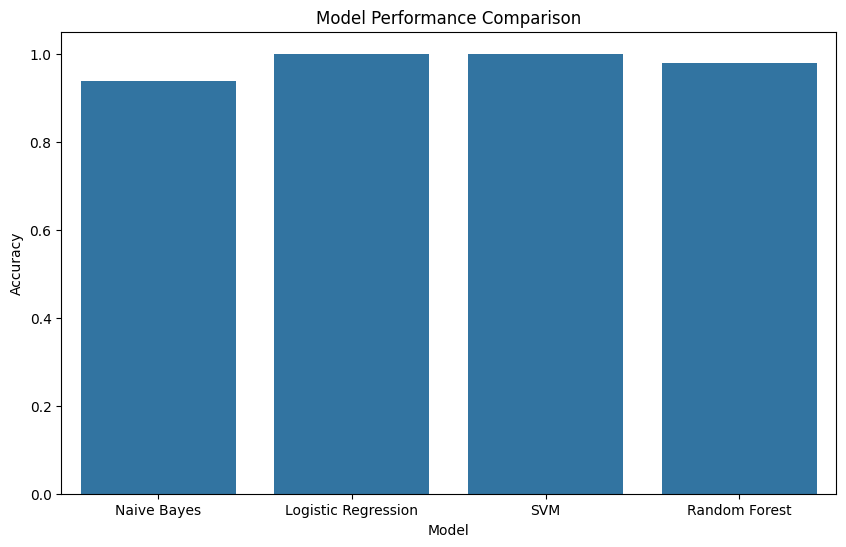

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming 'results' is a DataFrame containing your model names and their corresponding performance metrics
# Example:
results = pd.DataFrame({
'Model': ['Naive Bayes', 'Logistic Regression', 'SVM',"Random Forest"],
'Accuracy': [0.9381443298969072, 1.0, 1.0,0.979381443298969],
'F1-Score': [ 0.94, 1.0, 1.0, 0.98]})

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results)
plt.title('Model Performance Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.show()


In [5]:
models

[('Naive Bayes', MultinomialNB()),
 ('Logistic Regression', LogisticRegression(max_iter=1000)),
 ('SVM', SVC(kernel='linear')),
 ('Random Forest', RandomForestClassifier())]

In [6]:
svm=models[2]
lgr=models[1]

In [7]:
lgr2=lgr[1]

In [8]:
model=Pipeline([
        ('tfidf', TfidfVectorizer(max_features=1000)),
        ('classifier', lgr2)
    ])

In [9]:
final=model.fit(X_train,y_train)

In [10]:
model.predict(['''come to monday for test
'''])

array(['optional'], dtype=object)

In [11]:
import pickle
pickle.dump(model,open("model.pkl","wb"))

In [12]:
y_pred=model.predict(X_test)


In [13]:
accuracy_score(y_test, y_pred)

1.0

In [14]:
model.predict(['''Dear Students,
 

As part of the Anti Ragging Week from 12th - 18th August 2024, DEPSTAR is organizing a Debate Competition on “Say no to Ragging: A Debate Competition" for the students of DEPSTAR, CHARUSAT.


Date: 12th August 2024

Venue: 329

Time: 11:10 AM to 12:10 PM 


Kindly register for the event through the below given link: 
CLICK HERE TO PARTICIPATE

The attractive prize will be awarded to the 1st and 2nd best debater. 

Participants will be given e-certificates of participation.

Please find the attached brochure. 

Feel free to contact Prof. Kajal Parmar for any queries.'''])

array(['priority'], dtype=object)